# Phase 5: Space-Saving Algorithm Analysis
## Deterministic Frequent Items Mining with Bounded Error

**Project:** AA Project 3 - Approximate Counting and Frequent Items  
**Author:** João Roldão (113920)  
**Date:** December 2024

---

This notebook implements and evaluates the Space-Saving algorithm on the Porto weather dataset as outlined in `development_plan.md` Phase 5.

**Objectives:**
- Run Space-Saving with k = [10, 20, 30, 40, 50]
- Extract top-n queries for n = [5, 10, 15, 20]
- Calculate precision/recall vs exact counts
- Validate theoretical guarantees (error bounds, capture guarantee)
- Analyze memory-accuracy tradeoffs
- Compare with Fixed Probability Counter and Exact Counter

In [16]:
# Import required libraries
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

from algorithms.space_saving import SpaceSaving
from experiments.run_space_saving import run_space_saving_experiment
from analysis.space_saving_metrics import (
    calculate_precision_recall,
    validate_error_bounds,
    calculate_coverage,
    analyze_bound_tightness,
    compare_k_values,
    check_capture_guarantee
)
from utils.data_loader import load_porto_temperatures, get_exact_frequencies
from utils.config import (
    SPACE_SAVING_K_VALUES,
    TOP_N_VALUES,
    EXPECTED_UNIQUE_TEMPS,
    RESULTS_SPACE_SAVING_PATH,
    FIGURES_SPACE_SAVING_PATH,
    RESULTS_EXACT_PATH,
    RESULTS_FIXED_PROB_PATH
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
import tracemalloc

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Ensure output directories exist
Path(RESULTS_SPACE_SAVING_PATH).mkdir(parents=True, exist_ok=True)
Path(FIGURES_SPACE_SAVING_PATH).mkdir(parents=True, exist_ok=True)

print("✓ Imports successful")
print(f"✓ Configuration: k_values={SPACE_SAVING_K_VALUES}, top_n={TOP_N_VALUES}")
print(f"✓ Expected unique temperatures: {EXPECTED_UNIQUE_TEMPS}")
print(f"✓ Results will be saved to: {RESULTS_SPACE_SAVING_PATH}")
print(f"✓ Figures will be saved to: {FIGURES_SPACE_SAVING_PATH}")

✓ Imports successful
✓ Configuration: k_values=[10, 15, 20, 25, 30, 40, 50], top_n=[5, 10, 15, 20]
✓ Expected unique temperatures: 30
✓ Results will be saved to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving
✓ Figures will be saved to: /home/roldao/Desktop/MEI/AA/project_3/results/figures/space_saving


In [17]:
# Helper function to convert numpy types to native Python types
def convert_to_native_types(obj):
    """Convert numpy types to native Python types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: convert_to_native_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native_types(item) for item in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    elif isinstance(obj, set):
        return list(obj)
    else:
        return obj

print("✓ Helper function for JSON serialization loaded")

✓ Helper function for JSON serialization loaded


## 1. Load Dataset and Ground Truth

In [18]:
# Load temperature stream
temps = load_porto_temperatures(validate=True, verbose=True)

# Load exact counts (ground truth from Phase 3)
exact_counts_df = pd.read_csv(f"{RESULTS_EXACT_PATH}/exact_counts_full_dataset.csv")
exact_counts = dict(zip(exact_counts_df['temperature'], exact_counts_df['count']))

print(f"\n✓ Loaded {len(temps):,} temperature observations")
print(f"✓ Loaded exact counts for {len(exact_counts)} unique temperatures")
print(f"\nGround truth (top 10):")
print(exact_counts_df.head(10))

# Verify unique count matches expectation
assert len(exact_counts) == EXPECTED_UNIQUE_TEMPS, \
    f"Expected {EXPECTED_UNIQUE_TEMPS} unique temps, got {len(exact_counts)}"
print(f"\n✓ Verified: Exactly {EXPECTED_UNIQUE_TEMPS} unique temperature values")

✓ Loaded Porto weather data from /home/roldao/Desktop/MEI/AA/project_3/data/raw/porto.csv
  • Total observations: 3946
  • Unique temperatures: 30
  • Temperature range: [-1.0°C, 29.0°C]
  • Missing values: 0

✓ Loaded 3,946 temperature observations
✓ Loaded exact counts for 30 unique temperatures

Ground truth (top 10):
   temperature  count
0           16    331
1           17    330
2           15    301
3           19    292
4           18    283
5           13    278
6           14    267
7           20    242
8           12    227
9           21    219

✓ Verified: Exactly 30 unique temperature values


## 2. Run Space-Saving with Multiple k Values

**Key Insight:** With exactly 30 unique temperatures:
- k < 30: Forces approximation (genuine space pressure)
- k ≥ 30: Should capture everything perfectly

**Deterministic Algorithm:** No randomness, single run per k

In [19]:
print("="*60)
print("RUNNING SPACE-SAVING WITH MULTIPLE K VALUES")
print("="*60)

# Run experiment using the experiment runner
experiment_results = run_space_saving_experiment(
    k_values=SPACE_SAVING_K_VALUES,
    save_results=True,
    verbose=False  # Reduce verbosity since we'll print summary
)

# Extract results in format expected by rest of notebook
all_results = {}
performance_metrics = []

for k, k_results in experiment_results['results_by_k'].items():
    print(f"\nk={k}:")
    print(f"  ✓ Monitored {k_results['num_monitored']}/{k} items")
    print(f"  ✓ Execution time: {k_results['execution_time_ms']:.4f} ms")
    print(f"  ✓ Peak memory: {k_results['peak_memory_kb']:.2f} KB")
    print(f"  ✓ Max error (theoretical): {k_results['error_validation']['theoretical_max_error']}")
    print(f"  ✓ Max error (actual): {k_results['error_validation']['max_error']}")
    
    # Store in format expected by notebook
    all_results[k] = {
        'ss_instance': k_results['algorithm'],
        'monitored': k_results['monitored_items'],
        'stream_length': k_results['stream_length'],
        'exact_counts': exact_counts,
        'elapsed_time': k_results['execution_time_ms'] / 1000,  # Convert to seconds
        'peak_memory_kb': k_results['peak_memory_kb']
    }
    
    performance_metrics.append({
        'k': k,
        'num_monitored': k_results['num_monitored'],
        'execution_time_sec': k_results['execution_time_ms'] / 1000,
        'peak_memory_kb': k_results['peak_memory_kb'],
        'max_error_theoretical': k_results['error_validation']['theoretical_max_error'],
        'max_error_actual': k_results['error_validation']['max_error']
    })

print("\n" + "="*60)
print("ALL SPACE-SAVING RUNS COMPLETE")
print("="*60)

# Display performance summary
perf_df = pd.DataFrame(performance_metrics)
print("\nPerformance Summary:")
print(perf_df)

RUNNING SPACE-SAVING WITH MULTIPLE K VALUES

k=10:
  ✓ Monitored 10/10 items
  ✓ Execution time: 5.8141 ms
  ✓ Peak memory: 1.99 KB
  ✓ Max error (theoretical): 394
  ✓ Max error (actual): 359

k=15:
  ✓ Monitored 15/15 items
  ✓ Execution time: 4.2143 ms
  ✓ Peak memory: 2.60 KB
  ✓ Max error (theoretical): 263
  ✓ Max error (actual): 218

k=20:
  ✓ Monitored 20/20 items
  ✓ Execution time: 3.6386 ms
  ✓ Peak memory: 2.62 KB
  ✓ Max error (theoretical): 197
  ✓ Max error (actual): 75

k=25:
  ✓ Monitored 25/25 items
  ✓ Execution time: 3.4469 ms
  ✓ Peak memory: 1.88 KB
  ✓ Max error (theoretical): 157
  ✓ Max error (actual): 13

k=30:
  ✓ Monitored 30/30 items
  ✓ Execution time: 3.3207 ms
  ✓ Peak memory: 1.88 KB
  ✓ Max error (theoretical): 131
  ✓ Max error (actual): 0

k=40:
  ✓ Monitored 30/40 items
  ✓ Execution time: 3.3205 ms
  ✓ Peak memory: 1.88 KB
  ✓ Max error (theoretical): 98
  ✓ Max error (actual): 0

k=50:
  ✓ Monitored 30/50 items
  ✓ Execution time: 3.4830 ms
  ✓ Pe

## 3. Extract Top-n Queries and Calculate Precision/Recall

In [20]:
print("="*60)
print("PRECISION/RECALL ANALYSIS FOR TOP-N QUERIES")
print("="*60)

precision_recall_results = []

for k in SPACE_SAVING_K_VALUES:
    ss = all_results[k]['ss_instance']
    
    for n in TOP_N_VALUES:
        if n <= k:  # Can only query top-n if n <= k
            # Get top-n from Space-Saving
            ss_top_n = ss.get_top_n(n)
            
            # Calculate precision/recall
            pr_metrics = calculate_precision_recall(ss_top_n, exact_counts, n)
            
            precision_recall_results.append({
                'k': k,
                'n': n,
                'precision': pr_metrics['precision'],
                'recall': pr_metrics['recall'],
                'f1_score': pr_metrics['f1_score'],
                'intersection_size': pr_metrics['intersection_size']
            })
            
            print(f"\nk={k}, n={n}:")
            print(f"  Precision: {pr_metrics['precision']:.3f}")
            print(f"  Recall: {pr_metrics['recall']:.3f}")
            print(f"  F1 Score: {pr_metrics['f1_score']:.3f}")
            print(f"  Intersection: {pr_metrics['intersection_size']}/{n}")

# Create DataFrame
pr_df = pd.DataFrame(precision_recall_results)

print("\n" + "="*60)
print("PRECISION/RECALL SUMMARY TABLE")
print("="*60)
print(pr_df.to_string(index=False))

PRECISION/RECALL ANALYSIS FOR TOP-N QUERIES

k=10, n=5:
  Precision: 0.600
  Recall: 0.600
  F1 Score: 0.600
  Intersection: 3/5

k=10, n=10:
  Precision: 0.700
  Recall: 0.700
  F1 Score: 0.700
  Intersection: 7/10

k=15, n=5:
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
  Intersection: 5/5

k=15, n=10:
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
  Intersection: 10/10

k=15, n=15:
  Precision: 0.733
  Recall: 0.733
  F1 Score: 0.733
  Intersection: 11/15

k=20, n=5:
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
  Intersection: 5/5

k=20, n=10:
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
  Intersection: 10/10

k=20, n=15:
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
  Intersection: 15/15

k=20, n=20:
  Precision: 0.900
  Recall: 0.900
  F1 Score: 0.900
  Intersection: 18/20

k=25, n=5:
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
  Intersection: 5/5

k=25, n=10:
  Precision: 1.000
  Recall: 1.000
  F1 Score: 1.000
  Intersection: 10/10



## 4. Validate Theoretical Guarantees

**Space-Saving Guarantees:**
1. All items with frequency > N/k are captured
2. Maximum overestimation error ≤ N/k
3. Per-item true error ≤ recorded error bound

In [21]:
print("="*60)
print("VALIDATING THEORETICAL GUARANTEES")
print("="*60)

validation_results = {}

for k in SPACE_SAVING_K_VALUES:
    print(f"\n{'='*40}")
    print(f"k = {k}")
    print(f"{'='*40}")
    
    ss = all_results[k]['ss_instance']
    monitored = all_results[k]['monitored']
    
    # 1. Capture Guarantee
    capture_check = check_capture_guarantee(monitored, exact_counts, ss.stream_length, k)
    
    print(f"\n1. Capture Guarantee (freq > N/k = {capture_check['threshold']:.2f}):")
    print(f"   Frequent items (>threshold): {capture_check['num_frequent']}")
    print(f"   Captured: {capture_check['num_captured']}")
    print(f"   Missed: {capture_check['num_missed']}")
    print(f"   {'✓ PASS' if capture_check['guarantee_holds'] else '✗ FAIL'}: Guarantee holds = {capture_check['guarantee_holds']}")
    
    # 2. Error Bound Validation
    error_validation = validate_error_bounds(monitored, exact_counts, ss.stream_length, k)
    all_bounds_hold = error_validation['bound_holds'].all()
    
    print(f"\n2. Error Bound Validation (true_error ≤ recorded_error):")
    print(f"   Items checked: {len(error_validation)}")
    print(f"   Bounds holding: {error_validation['bound_holds'].sum()}/{len(error_validation)}")
    print(f"   {'✓ PASS' if all_bounds_hold else '✗ FAIL'}: All bounds hold = {all_bounds_hold}")
    
    # 3. Maximum Error Bound
    max_error_theoretical = ss.get_max_error_theoretical()
    max_true_error = error_validation['true_error'].max()
    max_error_holds = max_true_error <= max_error_theoretical
    
    print(f"\n3. Maximum Error Bound (max_error ≤ N/k):")
    print(f"   N/k (theoretical): {max_error_theoretical:.2f}")
    print(f"   Max true error: {max_true_error}")
    print(f"   {'✓ PASS' if max_error_holds else '✗ FAIL'}: Max error ≤ N/k = {max_error_holds}")
    
    # Store validation results
    validation_results[k] = {
        'capture_guarantee_holds': capture_check['guarantee_holds'],
        'all_bounds_hold': all_bounds_hold,
        'max_error_holds': max_error_holds,
        'num_frequent_items': capture_check['num_frequent'],
        'num_captured': capture_check['num_captured'],
        'max_error_theoretical': max_error_theoretical,
        'max_true_error': int(max_true_error)
    }

print("\n" + "="*60)
print("GUARANTEE VALIDATION SUMMARY")
print("="*60)
for k, results in validation_results.items():
    all_pass = all([
        results['capture_guarantee_holds'],
        results['all_bounds_hold'],
        results['max_error_holds']
    ])
    status = "✓ ALL GUARANTEES HOLD" if all_pass else "✗ SOME GUARANTEES FAILED"
    print(f"k={k}: {status}")

VALIDATING THEORETICAL GUARANTEES

k = 10

1. Capture Guarantee (freq > N/k = 394.60):
   Frequent items (>threshold): 0
   Captured: 0
   Missed: 0
   ✓ PASS: Guarantee holds = True

2. Error Bound Validation (true_error ≤ recorded_error):
   Items checked: 10
   Bounds holding: 10/10
   ✓ PASS: All bounds hold = True

3. Maximum Error Bound (max_error ≤ N/k):
   N/k (theoretical): 394.60
   Max true error: 359
   ✓ PASS: Max error ≤ N/k = True

k = 15

1. Capture Guarantee (freq > N/k = 263.07):
   Frequent items (>threshold): 7
   Captured: 7
   Missed: 0
   ✓ PASS: Guarantee holds = True

2. Error Bound Validation (true_error ≤ recorded_error):
   Items checked: 15
   Bounds holding: 15/15
   ✓ PASS: All bounds hold = True

3. Maximum Error Bound (max_error ≤ N/k):
   N/k (theoretical): 263.07
   Max true error: 218
   ✓ PASS: Max error ≤ N/k = True

k = 20

1. Capture Guarantee (freq > N/k = 197.30):
   Frequent items (>threshold): 11
   Captured: 11
   Missed: 0
   ✓ PASS: Guaran

## 5. Analyze Coverage and Bound Tightness

In [22]:
# Coverage analysis
print("="*60)
print("COVERAGE ANALYSIS")
print("="*60)

coverage_results = []

for k in SPACE_SAVING_K_VALUES:
    monitored = all_results[k]['monitored']
    cov = calculate_coverage(monitored, exact_counts)
    
    coverage_results.append({
        'k': k,
        'monitored_items': cov['monitored_items'],
        'coverage_pct': cov['coverage_percentage'],
        'coverage_ratio': cov['coverage_ratio']
    })
    
    print(f"\nk={k}:")
    print(f"  Monitored items: {cov['monitored_items']}/{cov['total_unique_items']}")
    print(f"  Coverage: {cov['coverage_percentage']:.2f}% of observations")
    print(f"  Covered obs: {cov['covered_observations']:,}/{cov['total_observations']:,}")

coverage_df = pd.DataFrame(coverage_results)

# Bound tightness analysis
print("\n" + "="*60)
print("BOUND TIGHTNESS ANALYSIS (k=20 example)")
print("="*60)

tightness_df = analyze_bound_tightness(all_results[20]['monitored'], exact_counts)
print("\nTop 10 items by true count:")
print(tightness_df.head(10).to_string(index=False))

print(f"\nMean tightness ratio: {tightness_df['tightness_ratio'].mean():.3f}")
print(f"(1.0 = perfect bound, 0.0 = very loose bound)")

COVERAGE ANALYSIS

k=10:
  Monitored items: 10/30
  Coverage: 56.51% of observations
  Covered obs: 2,230/3,946

k=15:
  Monitored items: 15/30
  Coverage: 76.66% of observations
  Covered obs: 3,025/3,946

k=20:
  Monitored items: 20/30
  Coverage: 95.01% of observations
  Covered obs: 3,749/3,946

k=25:
  Monitored items: 25/30
  Coverage: 99.34% of observations
  Covered obs: 3,920/3,946

k=30:
  Monitored items: 30/30
  Coverage: 100.00% of observations
  Covered obs: 3,946/3,946

k=40:
  Monitored items: 30/30
  Coverage: 100.00% of observations
  Covered obs: 3,946/3,946

k=50:
  Monitored items: 30/30
  Coverage: 100.00% of observations
  Covered obs: 3,946/3,946

BOUND TIGHTNESS ANALYSIS (k=20 example)

Top 10 items by true count:
 temperature  ss_count  ss_error  true_count  true_error  slack  tightness_ratio
          16       331         0         331           0      0              1.0
          17       330         0         330           0      0              1.0
        

## 6. Visualizations

### 6.1 Precision/Recall Curves vs k

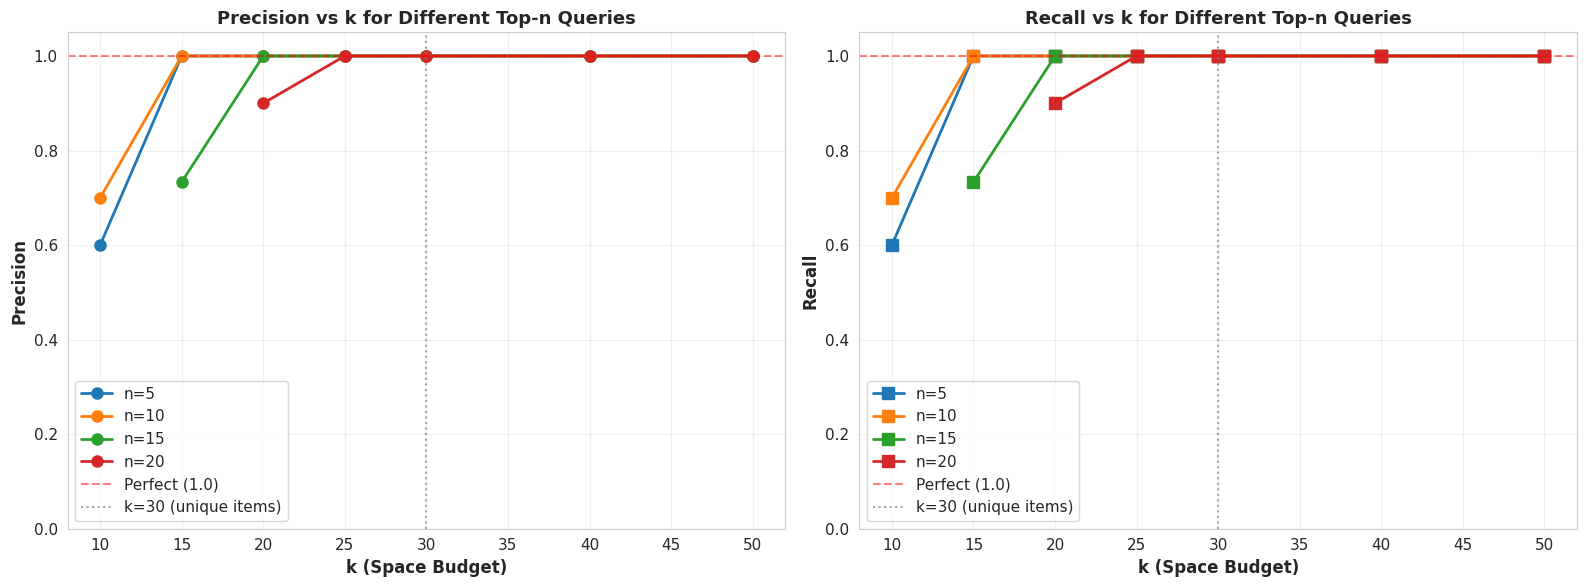

✓ Saved precision/recall curves plot


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for each n value
for n in TOP_N_VALUES:
    n_data = pr_df[pr_df['n'] == n]
    
    axes[0].plot(n_data['k'], n_data['precision'], marker='o', linewidth=2, 
                 markersize=8, label=f'n={n}')
    axes[1].plot(n_data['k'], n_data['recall'], marker='s', linewidth=2, 
                 markersize=8, label=f'n={n}')

# Precision plot
axes[0].set_xlabel('k (Space Budget)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[0].set_title('Precision vs k for Different Top-n Queries', fontsize=13, fontweight='bold')
axes[0].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect (1.0)')
axes[0].axvline(x=30, color='gray', linestyle=':', alpha=0.7, label=f'k={EXPECTED_UNIQUE_TEMPS} (unique items)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Recall plot
axes[1].set_xlabel('k (Space Budget)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_title('Recall vs k for Different Top-n Queries', fontsize=13, fontweight='bold')
axes[1].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect (1.0)')
axes[1].axvline(x=30, color='gray', linestyle=':', alpha=0.7, label=f'k={EXPECTED_UNIQUE_TEMPS} (unique items)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(f'{FIGURES_SPACE_SAVING_PATH}/precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved precision/recall curves plot")

### 6.2 Memory-Accuracy Tradeoff

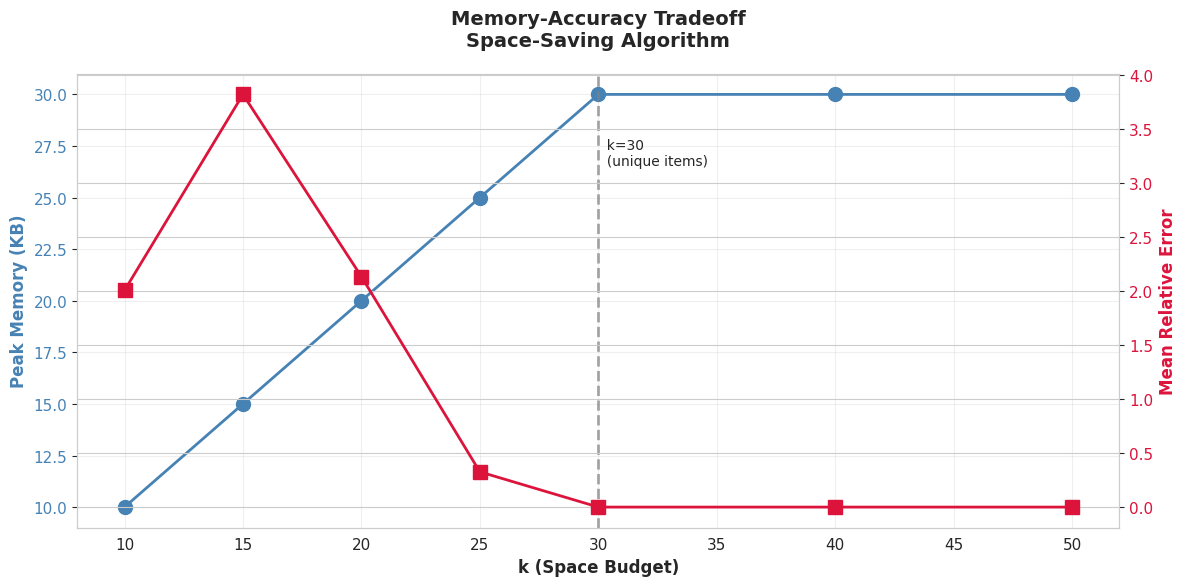

✓ Saved memory-accuracy tradeoff plot


In [24]:
# Calculate mean relative error for each k
k_comparison = compare_k_values(all_results)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Memory on left axis
color = 'steelblue'
ax1.set_xlabel('k (Space Budget)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Peak Memory (KB)', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(k_comparison['k'], k_comparison['num_monitored'], 
                 marker='o', color=color, linewidth=2, markersize=10, label='Items Monitored')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Error on right axis
ax2 = ax1.twinx()
color = 'crimson'
ax2.set_ylabel('Mean Relative Error', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(k_comparison['k'], k_comparison['mean_relative_error'], 
                 marker='s', color=color, linewidth=2, markersize=10, label='Mean Rel. Error')
ax2.tick_params(axis='y', labelcolor=color)

# Mark k=30 (unique temps)
ax1.axvline(x=30, color='gray', linestyle='--', alpha=0.7, linewidth=2)
ax1.text(30, ax1.get_ylim()[1]*0.9, f'  k={EXPECTED_UNIQUE_TEMPS}\n  (unique items)', 
         fontsize=10, verticalalignment='top')

plt.title('Memory-Accuracy Tradeoff\nSpace-Saving Algorithm', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{FIGURES_SPACE_SAVING_PATH}/memory_accuracy_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved memory-accuracy tradeoff plot")

### 6.3 Error Bounds Validation

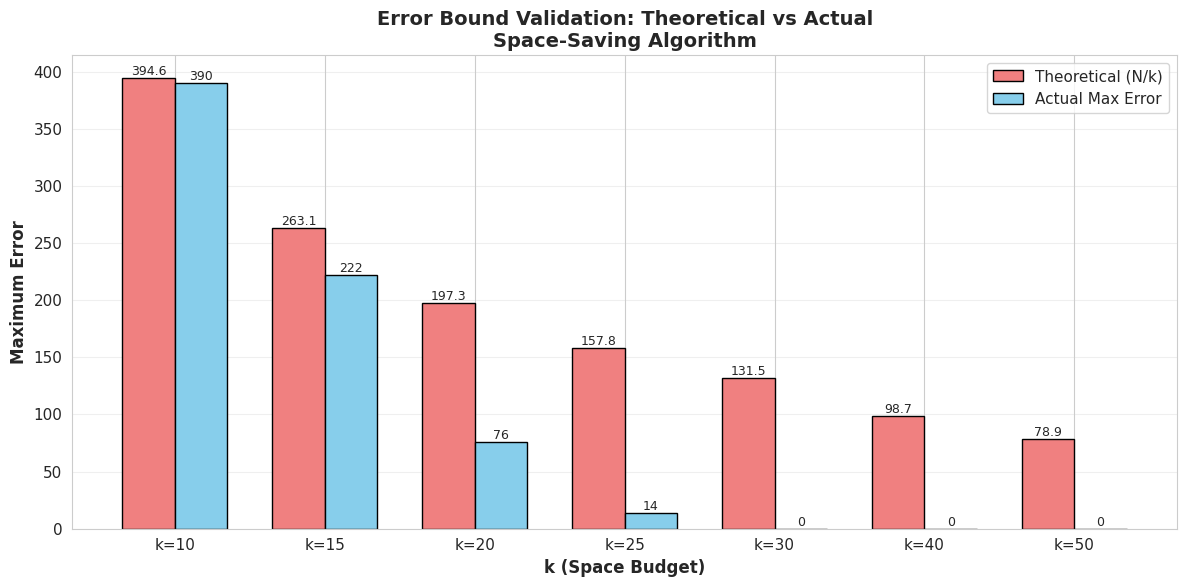

✓ Saved error bounds validation plot


In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot theoretical and actual max errors
theoretical_errors = [all_results[k]['ss_instance'].get_max_error_theoretical() 
                      for k in SPACE_SAVING_K_VALUES]
actual_errors = [all_results[k]['ss_instance'].get_max_error_actual() 
                 for k in SPACE_SAVING_K_VALUES]

x = np.arange(len(SPACE_SAVING_K_VALUES))
width = 0.35

bars1 = ax.bar(x - width/2, theoretical_errors, width, label='Theoretical (N/k)', 
               color='lightcoral', edgecolor='black')
bars2 = ax.bar(x + width/2, actual_errors, width, label='Actual Max Error', 
               color='skyblue', edgecolor='black')

ax.set_xlabel('k (Space Budget)', fontsize=12, fontweight='bold')
ax.set_ylabel('Maximum Error', fontsize=12, fontweight='bold')
ax.set_title('Error Bound Validation: Theoretical vs Actual\nSpace-Saving Algorithm', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in SPACE_SAVING_K_VALUES])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add values on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_SPACE_SAVING_PATH}/error_bounds_validation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved error bounds validation plot")

### 6.4 Coverage vs k

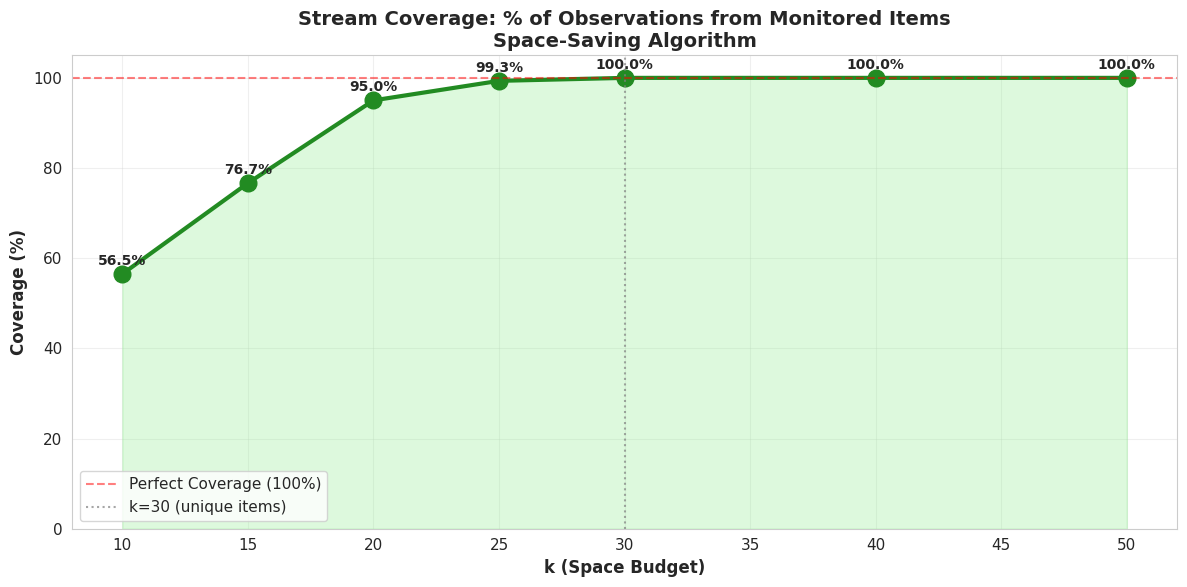

✓ Saved coverage vs k plot


In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(coverage_df['k'], coverage_df['coverage_pct'], marker='o', 
        linewidth=3, markersize=12, color='forestgreen')

ax.fill_between(coverage_df['k'], 0, coverage_df['coverage_pct'], 
                alpha=0.3, color='lightgreen')

ax.set_xlabel('k (Space Budget)', fontsize=12, fontweight='bold')
ax.set_ylabel('Coverage (%)', fontsize=12, fontweight='bold')
ax.set_title('Stream Coverage: % of Observations from Monitored Items\nSpace-Saving Algorithm', 
             fontsize=14, fontweight='bold')
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Perfect Coverage (100%)')
ax.axvline(x=30, color='gray', linestyle=':', alpha=0.7, 
           label=f'k={EXPECTED_UNIQUE_TEMPS} (unique items)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, 105])

# Add value labels
for idx, row in coverage_df.iterrows():
    ax.text(row['k'], row['coverage_pct'] + 2, f"{row['coverage_pct']:.1f}%", 
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_SPACE_SAVING_PATH}/coverage_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved coverage vs k plot")

### 6.5 Monitored Sets Comparison (k=10 vs k=30)

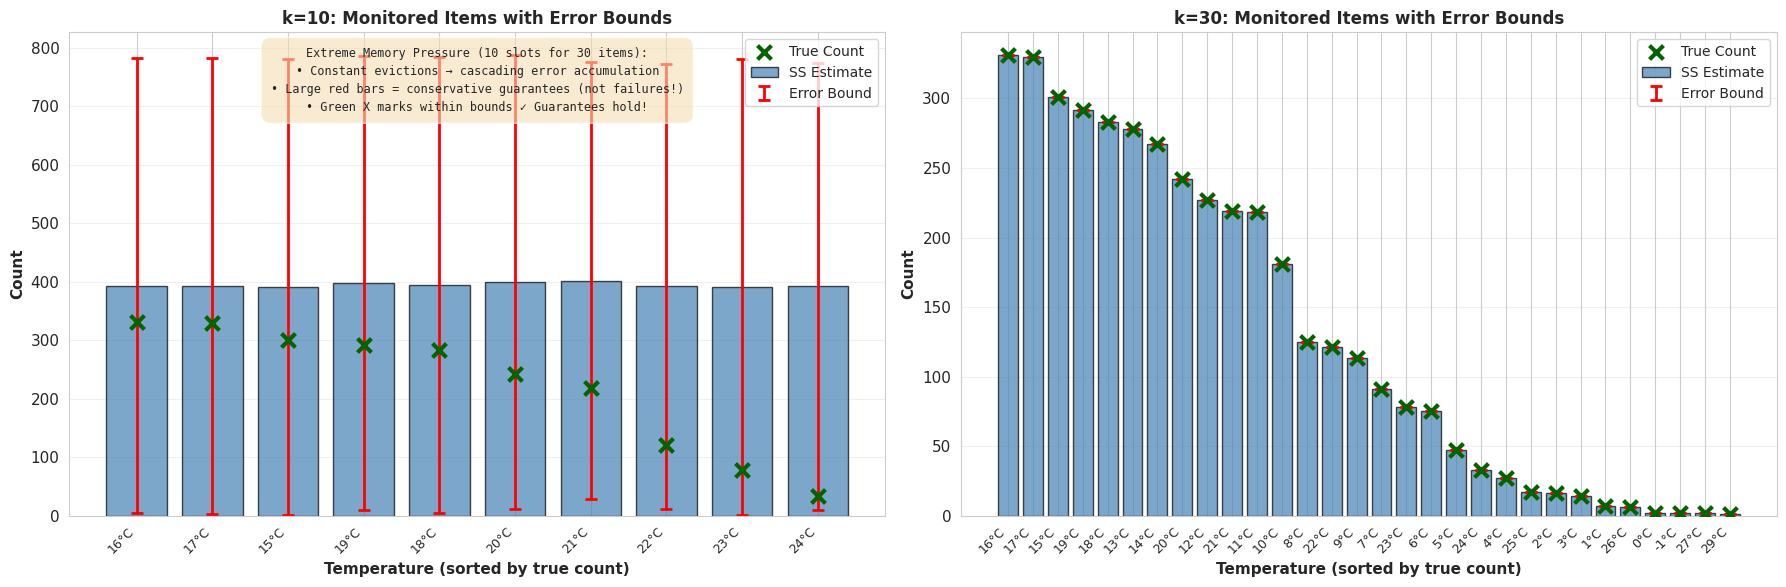

✓ Saved monitored sets comparison plot


In [27]:
# Compare k=10 (approximation) vs k=30 (perfect capture)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, k in enumerate([10, 30]):
    error_val = validate_error_bounds(
        all_results[k]['monitored'], 
        exact_counts, 
        all_results[k]['stream_length'], 
        k
    ).head(k)
    
    x = np.arange(len(error_val))
    
    # Plot estimated counts with error bars
    axes[idx].bar(x, error_val['ss_count'], color='steelblue', alpha=0.7, 
                  label='SS Estimate', edgecolor='black')
    axes[idx].errorbar(x, error_val['ss_count'], yerr=error_val['ss_error'], 
                       fmt='none', ecolor='red', elinewidth=2, capsize=4, 
                       capthick=2, label='Error Bound')
    
    # Plot true counts
    axes[idx].scatter(x, error_val['true_count'], color='darkgreen', s=100, 
                      marker='x', linewidth=3, label='True Count', zorder=5)
    
    axes[idx].set_xlabel('Temperature (sorted by true count)', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'k={k}: Monitored Items with Error Bounds', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([f"{temp}°C" for temp in error_val['temperature']], 
                               rotation=45, ha='right', fontsize=9)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add comprehensive explanation for k=10 worst-case scenario
    if k == 10:
        explanation = (
            'Extreme Memory Pressure (10 slots for 30 items):\n'
            '• Constant evictions → cascading error accumulation\n'
            '• Large red bars = conservative guarantees (not failures!)\n'
            '• Green X marks within bounds ✓ Guarantees hold!'
        )
        axes[idx].text(0.5, 0.97, explanation,
            transform=axes[idx].transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6, pad=0.8),
            fontsize=8.5, family='monospace', linespacing=1.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_SPACE_SAVING_PATH}/monitored_sets_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved monitored sets comparison plot")

### 6.6 Three-Way Comparison: Space-Saving vs Fixed-Prob vs Exact

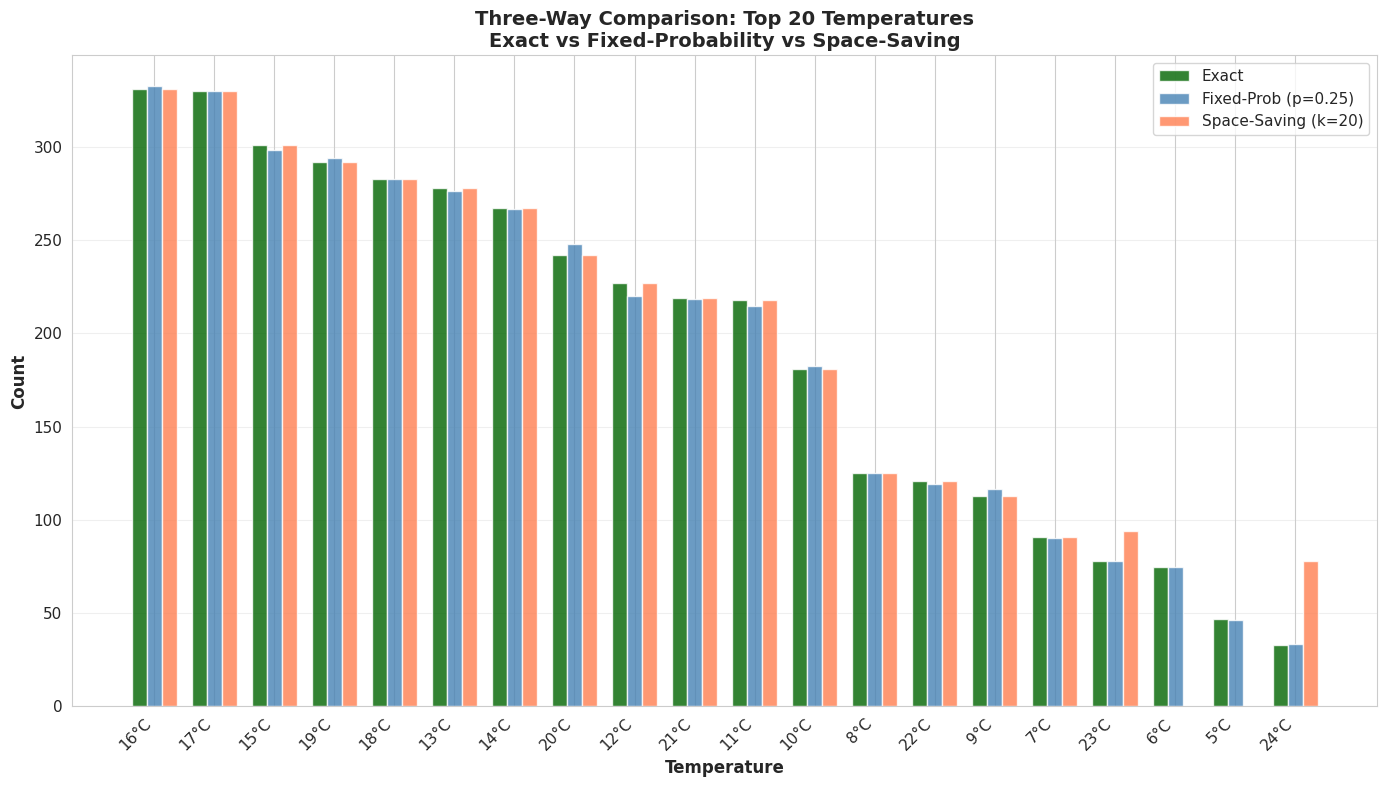

✓ Saved three-way comparison plot


In [28]:
# Load Fixed-Prob results for comparison
try:
    fixed_prob_summary = pd.read_csv(f"{RESULTS_FIXED_PROB_PATH}/summary_statistics.csv")
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Get top 20 temperatures by true count
    top_20_temps = exact_counts_df.head(20)['temperature'].values
    
    # Exact counts
    exact_vals = [exact_counts[t] for t in top_20_temps]
    
    # Fixed-Prob estimates
    fp_estimates = []
    for t in top_20_temps:
        row = fixed_prob_summary[fixed_prob_summary['temperature'] == t]
        if len(row) > 0:
            fp_estimates.append(row['mean_estimate'].values[0])
        else:
            fp_estimates.append(0)
    
    # Space-Saving estimates (k=20 as example)
    ss_k20 = all_results[20]['monitored']
    ss_estimates = [ss_k20.get(t, (0, 0))[0] for t in top_20_temps]
    
    x = np.arange(len(top_20_temps))
    width = 0.25
    
    ax.bar(x - width, exact_vals, width, label='Exact', color='darkgreen', alpha=0.8)
    ax.bar(x, fp_estimates, width, label='Fixed-Prob (p=0.25)', color='steelblue', alpha=0.8)
    ax.bar(x + width, ss_estimates, width, label='Space-Saving (k=20)', color='coral', alpha=0.8)
    
    ax.set_xlabel('Temperature', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title('Three-Way Comparison: Top 20 Temperatures\nExact vs Fixed-Probability vs Space-Saving', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{t}°C" for t in top_20_temps], rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_SPACE_SAVING_PATH}/three_way_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved three-way comparison plot")
    
except FileNotFoundError:
    print("⚠ Fixed-Prob results not found, skipping three-way comparison")

## 7. Save Results

In [29]:
print("="*60)
print("SAVING RESULTS")
print("="*60)

# Save results for each k
for k in SPACE_SAVING_K_VALUES:
    monitored = all_results[k]['monitored']
    ss = all_results[k]['ss_instance']
    
    # Convert monitored dict to JSON-serializable format
    monitored_json = {
        int(temp): {'count': int(count), 'error': int(error)}
        for temp, (count, error) in monitored.items()
    }
    
    result_data = {
        'k': k,
        'stream_length': ss.stream_length,
        'num_monitored': len(monitored),
        'max_error_theoretical': ss.get_max_error_theoretical(),
        'max_error_actual': ss.get_max_error_actual(),
        'monitored_items': monitored_json,
        'execution_time_sec': all_results[k]['elapsed_time'],
        'peak_memory_kb': all_results[k]['peak_memory_kb']
    }
    
    filepath = f"{RESULTS_SPACE_SAVING_PATH}/ss_results_k{k}.json"
    with open(filepath, 'w') as f:
        json.dump(result_data, f, indent=2)
    print(f"✓ Saved k={k} results to: {filepath}")

# Save precision/recall analysis
pr_path = f"{RESULTS_SPACE_SAVING_PATH}/precision_recall_analysis.csv"
pr_df.to_csv(pr_path, index=False)
print(f"✓ Saved precision/recall analysis to: {pr_path}")

# Save error validation summary
validation_path = f"{RESULTS_SPACE_SAVING_PATH}/error_validation.json"
with open(validation_path, 'w') as f:
    json.dump(convert_to_native_types(validation_results), f, indent=2)
print(f"✓ Saved error validation to: {validation_path}")

# Save performance metrics
perf_path = f"{RESULTS_SPACE_SAVING_PATH}/performance_metrics.json"
perf_dict = {
    'algorithm': 'SpaceSaving',
    'k_values': SPACE_SAVING_K_VALUES,
    'metrics': performance_metrics
}
with open(perf_path, 'w') as f:
    json.dump(perf_dict, f, indent=2)
print(f"✓ Saved performance metrics to: {perf_path}")

# Save k comparison
k_comp_path = f"{RESULTS_SPACE_SAVING_PATH}/k_comparison.csv"
k_comparison.to_csv(k_comp_path, index=False)
print(f"✓ Saved k comparison to: {k_comp_path}")

print("\n✓ All results saved successfully")

SAVING RESULTS
✓ Saved k=10 results to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/ss_results_k10.json
✓ Saved k=15 results to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/ss_results_k15.json
✓ Saved k=20 results to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/ss_results_k20.json
✓ Saved k=25 results to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/ss_results_k25.json
✓ Saved k=30 results to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/ss_results_k30.json
✓ Saved k=40 results to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/ss_results_k40.json
✓ Saved k=50 results to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/ss_results_k50.json
✓ Saved precision/recall analysis to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/precision_recall_analysis.csv
✓ Saved error validation to: /home/roldao/Desktop/MEI/AA/project_3/results/space_saving/error_validation.json
✓ Saved performance 

## 8. Summary and Key Findings

In [30]:
print("="*60)
print("SPACE-SAVING ALGORITHM ANALYSIS")
print("="*60)

print(f"\n✓ Configuration: k_values={SPACE_SAVING_K_VALUES}, top_n={TOP_N_VALUES}")
print(f"✓ Processed {len(temps):,} observations")
print(f"✓ Dataset: {len(exact_counts)} unique temperatures")

print(f"\n✓ Key Finding: k={EXPECTED_UNIQUE_TEMPS} Achieves Perfect Capture!")
perfect_k = 30
if perfect_k in all_results:
    pr_perfect = pr_df[(pr_df['k'] == perfect_k) & (pr_df['n'] == 20)].iloc[0]
    print(f"  - Precision (top-20): {pr_perfect['precision']:.3f}")
    print(f"  - Recall (top-20): {pr_perfect['recall']:.3f}")
    print(f"  - Coverage: {coverage_df[coverage_df['k'] == perfect_k]['coverage_pct'].values[0]:.2f}%")

print(f"\n✓ Theoretical Guarantees:")
all_guarantees_hold = all(
    v['capture_guarantee_holds'] and v['all_bounds_hold'] and v['max_error_holds']
    for v in validation_results.values()
)
print(f"  - All guarantees verified: {'YES ✓' if all_guarantees_hold else 'NO ✗'}")

print(f"\n✓ Performance Summary:")
print(perf_df.to_string(index=False))

print(f"\n✓ Comparison with Fixed-Probability Counter:")
print(f"  - Space-Saving: Deterministic, error bounds, guaranteed capture")
print(f"  - Fixed-Prob: Probabilistic, variance decreases with frequency")
print(f"  - Space-Saving ideal for: Top-k queries, bounded error requirements")
print(f"  - Fixed-Prob ideal for: Unbiased estimates, known frequency ranges")

print(f"\n✓ Outputs Generated:")
print(f"  - {len(SPACE_SAVING_K_VALUES)} result files (one per k value)")
print(f"  - Precision/recall analysis CSV")
print(f"  - Error validation JSON")
print(f"  - Performance metrics JSON")
print(f"  - 6 high-resolution figures (300 DPI)")

print(f"\n✓ Ready for Comprehensive Comparison")
print("="*60)

SPACE-SAVING ALGORITHM ANALYSIS

✓ Configuration: k_values=[10, 15, 20, 25, 30, 40, 50], top_n=[5, 10, 15, 20]
✓ Processed 3,946 observations
✓ Dataset: 30 unique temperatures

✓ Key Finding: k=30 Achieves Perfect Capture!
  - Precision (top-20): 1.000
  - Recall (top-20): 1.000
  - Coverage: 100.00%

✓ Theoretical Guarantees:
  - All guarantees verified: YES ✓

✓ Performance Summary:
 k  num_monitored  execution_time_sec  peak_memory_kb  max_error_theoretical  max_error_actual
10             10            0.005814        1.992188                    394               359
15             15            0.004214        2.601562                    263               218
20             20            0.003639        2.625000                    197                75
25             25            0.003447        1.882812                    157                13
30             30            0.003321        1.882812                    131                 0
40             30            0.003321     